Importing the Necessary Modules

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot
import random
import json
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go

Connecting to the Database

In [2]:
db_username_0 = 'simulationuser'
db_password_0 = 'simulations2024'
db_host_0 = 'localhost'
db_port_0 = '5432'
db_name_0 = 'simulations_data'
table_name_0 = 'composite_data'

In [3]:
connection_string = f"postgresql://{db_username_0}:{db_password_0}@{db_host_0}:{db_port_0}/{db_name_0}"
engine = create_engine(connection_string)
query = f"SELECT * FROM {table_name_0}"
df = pd.read_sql(query, engine)

The DataFrame

In [4]:
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list
0,1500,0.123943,318.864022,"[-0.011744609035812982, -0.011215305626181015,...","[-5.517162102724528, -3.1920707854231463, -0.9...","[-0.0016475367466768115, -0.002355776502265530...","[10.73076649947905, 10.77581128940965, 10.5402...","[0.4615413218450946, 0.4686702377764153, 0.478...","[0.6551578220909112, 0.8945764375320215, 1.175...","[0.00013793584140409996, 0.0001257830802886475...","[30.43907766773974, 10.189315899151941, 0.8663...","[2.7143773316504123e-06, 5.549682928626416e-06...","[115.14934966634185, 116.11810894496844, 111.0...","[0.06479691188370344, 0.035800049438924265, 0....","[-0.1260286571909809, -0.12085401698078094, -0...","[0.009089727301611367, 0.007519805349868124, 0...","[-59.203378264111755, -34.39715240615747, -9.8...","[-0.01767933212790023, -0.025385403028438877, ...","[[1.0369206541904592], [-1.6813054180526377], ..."
1,1501,0.123943,318.864022,"[-0.008147157474100065, -0.008292099833020762,...","[-0.832904729882089, 0.14071461474575664, 1.27...","[0.0006807256129005129, 0.0007313699095774325,...","[-0.7190970906032216, -0.6095182673572732, -0....","[0.23703131704960073, 0.23479400902756253, 0.2...","[-0.18778048603775238, -0.2053401462453807, -0...","[6.637617490778455e-05, 6.875891964078295e-05,...","[0.6937302890599556, 0.019800602803046713, 1.6...","[4.6338736005877887e-07, 5.349019446353018e-07...","[0.5171006257140178, 0.3715125182422124, 0.293...","[0.006785805995272157, -0.0011668196334368695,...","[0.005858597236311648, 0.005054186322976349, 0...","[-0.0005669795827367211, 0.0001029144350628272...","[0.5989393680078723, -0.0857681281716798, -0.6...","[-0.0004895078077358536, -0.000445783320082882...","[[1.418213787060706], [0.8827834628841255], [0..."
2,1502,0.123943,318.864022,"[-0.003781434990007615, -0.001308768972368787,...","[7.429632504232679, 7.616174400779771, 7.45893...","[0.0017201097552821953, 0.0016973192181066884,...","[0.26192796713213556, -0.016191321040263613, -...","[0.3398928494975913, 0.33847860008307173, 0.33...","[-0.22023434840890527, -0.0752140155360062, 0....","[1.4299250583653892e-05, 1.7128762230352505e-0...","[55.199439147950756, 58.00611250309311, 55.635...","[2.958777570216974e-06, 2.8808925281543e-06, 2...","[0.06860625996597308, 0.0002621588770288832, 0...","[-0.028094672314403355, -0.009967812743890003,...","[-0.000990463579775022, 2.1190698599158928e-05...","[0.012779783348692317, 0.012927079178895698, 0...","[1.9460285383725033, -0.12331592482166262, -2....","[0.00045054485144522063, -2.7481840368174608e-...","[[-0.6679438799496836], [-0.8041216677662598],..."
3,1503,0.123943,318.864022,"[-0.008102021680746106, -0.007577287179778589,...","[-13.405475487140006, -12.142974722866745, -10...","[-0.007065355563569785, -0.007211423776971252,...","[3.432058579711073, 2.9279736455346024, 2.4210...","[0.15021463519080008, 0.17082991418834997, 0.1...","[1.9382048681079675, 1.850150346137473, 2.4148...","[6.564275531527996e-05, 5.7415281004836965e-05...","[179.70677303631157, 147.4518351201807, 119.05...","[4.991924923966652e-05, 5.2004632891066315e-05...","[11.779026094568387, 8.573029668945189, 5.8616...","[0.10861145303751879, 0.09201080669195365, 0.1...","[-0.0278066130224098, -0.022186097167038923, -...","[0.09471445081536302, 0.08756813663964214, 0.0...","[-46.00837716074533, -35.55430996694667, -26.4...","[-0.024248714180659044, -0.021114858765753426,...","[[0.20668630436664126], [1.0343110874926529], ..."
4,1504,0.123943,318.864022,"[-0.0007052290130828054, -0.003475921446700475...","[7.188510348955567, 7.255315274332748, 7.40112...","[0.01155266108186768, 0.011468163968599393, 0....","[-0.9665805895951766, 0.23618988496103174, 1.4...","[0.1388431307750241, 0.13278906064134477, 0.12...","[-0.2758572865676108, -1.349696442983

Space Plots


Verifying Details

In [5]:
def length_of_the_first_entry(series):
    return len(series.iloc[0])

selected_columns = df.iloc[:,3:]

lengths = selected_columns.apply(length_of_the_first_entry)
lengths

psi_e                          1000
b_e                            1000
psi_plus                       1000
b_plus                         1000
u_list                         1000
r_list                         1000
k_e_psi_e_list                 1000
k_e_b_e_list                   1000
k_e_psi_plus_list              1000
k_e_b_plus_list                1000
heat_flux_psi_e_b_e_list       1000
heat_flux_psi_e_b_plus_list    1000
b_e_psi_plus_list              1000
b_e_b_plus_list                1000
psi_plus_b_plus_list           1000
eta_list                       1000
dtype: int64

Defining Common Functions

In [6]:
def average_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = np.array([np.array(arr) for arr in arrays])
    array_lengths = np.array([len(arr) for arr in np_arrays])

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    # average_array = np.sqrt(np.mean(np_arrays**2, axis=0))
    average_array = np.mean(np_arrays, axis=0)

    
    return average_array

Composite Analysis of All the Data

In [7]:
average_psi_e = average_arrays(*list(df['psi_e']))
average_b_e = average_arrays(*list(df['b_e']))
average_psi_plus = average_arrays(*list(df['psi_plus']))
average_b_plus = average_arrays(*list(df['b_plus']))
average_U = average_arrays(*list(df['u_list']))
average_R = average_arrays(*list(df['r_list']))
average_k_e_psi_e_list = average_arrays(*list(df['k_e_psi_e_list']))
average_k_e_b_e_list = average_arrays(*list(df['k_e_b_e_list']))
average_k_e_psi_plus_list = average_arrays(*list(df['k_e_psi_plus_list']))
average_k_e_b_plus_list = average_arrays(*list(df['k_e_b_plus_list']))
average_heat_flux_psi_e_b_e_list = average_arrays(*list(df['heat_flux_psi_e_b_e_list']))
average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df['heat_flux_psi_e_b_plus_list']))
average_b_e_psi_plus_list = average_arrays(*list(df['b_e_psi_plus_list']))
average_b_e_b_plus_list = average_arrays(*list(df['b_e_b_plus_list']))
average_psi_plus_b_plus_list = average_arrays(*list(df['psi_plus_b_plus_list']))
average_eta = average_arrays(*list(df['eta_list']))

In [8]:
window_size = 5000
dt = .001
epsilon = 0.12394270273516043
N_0_squared = 318.8640217310387

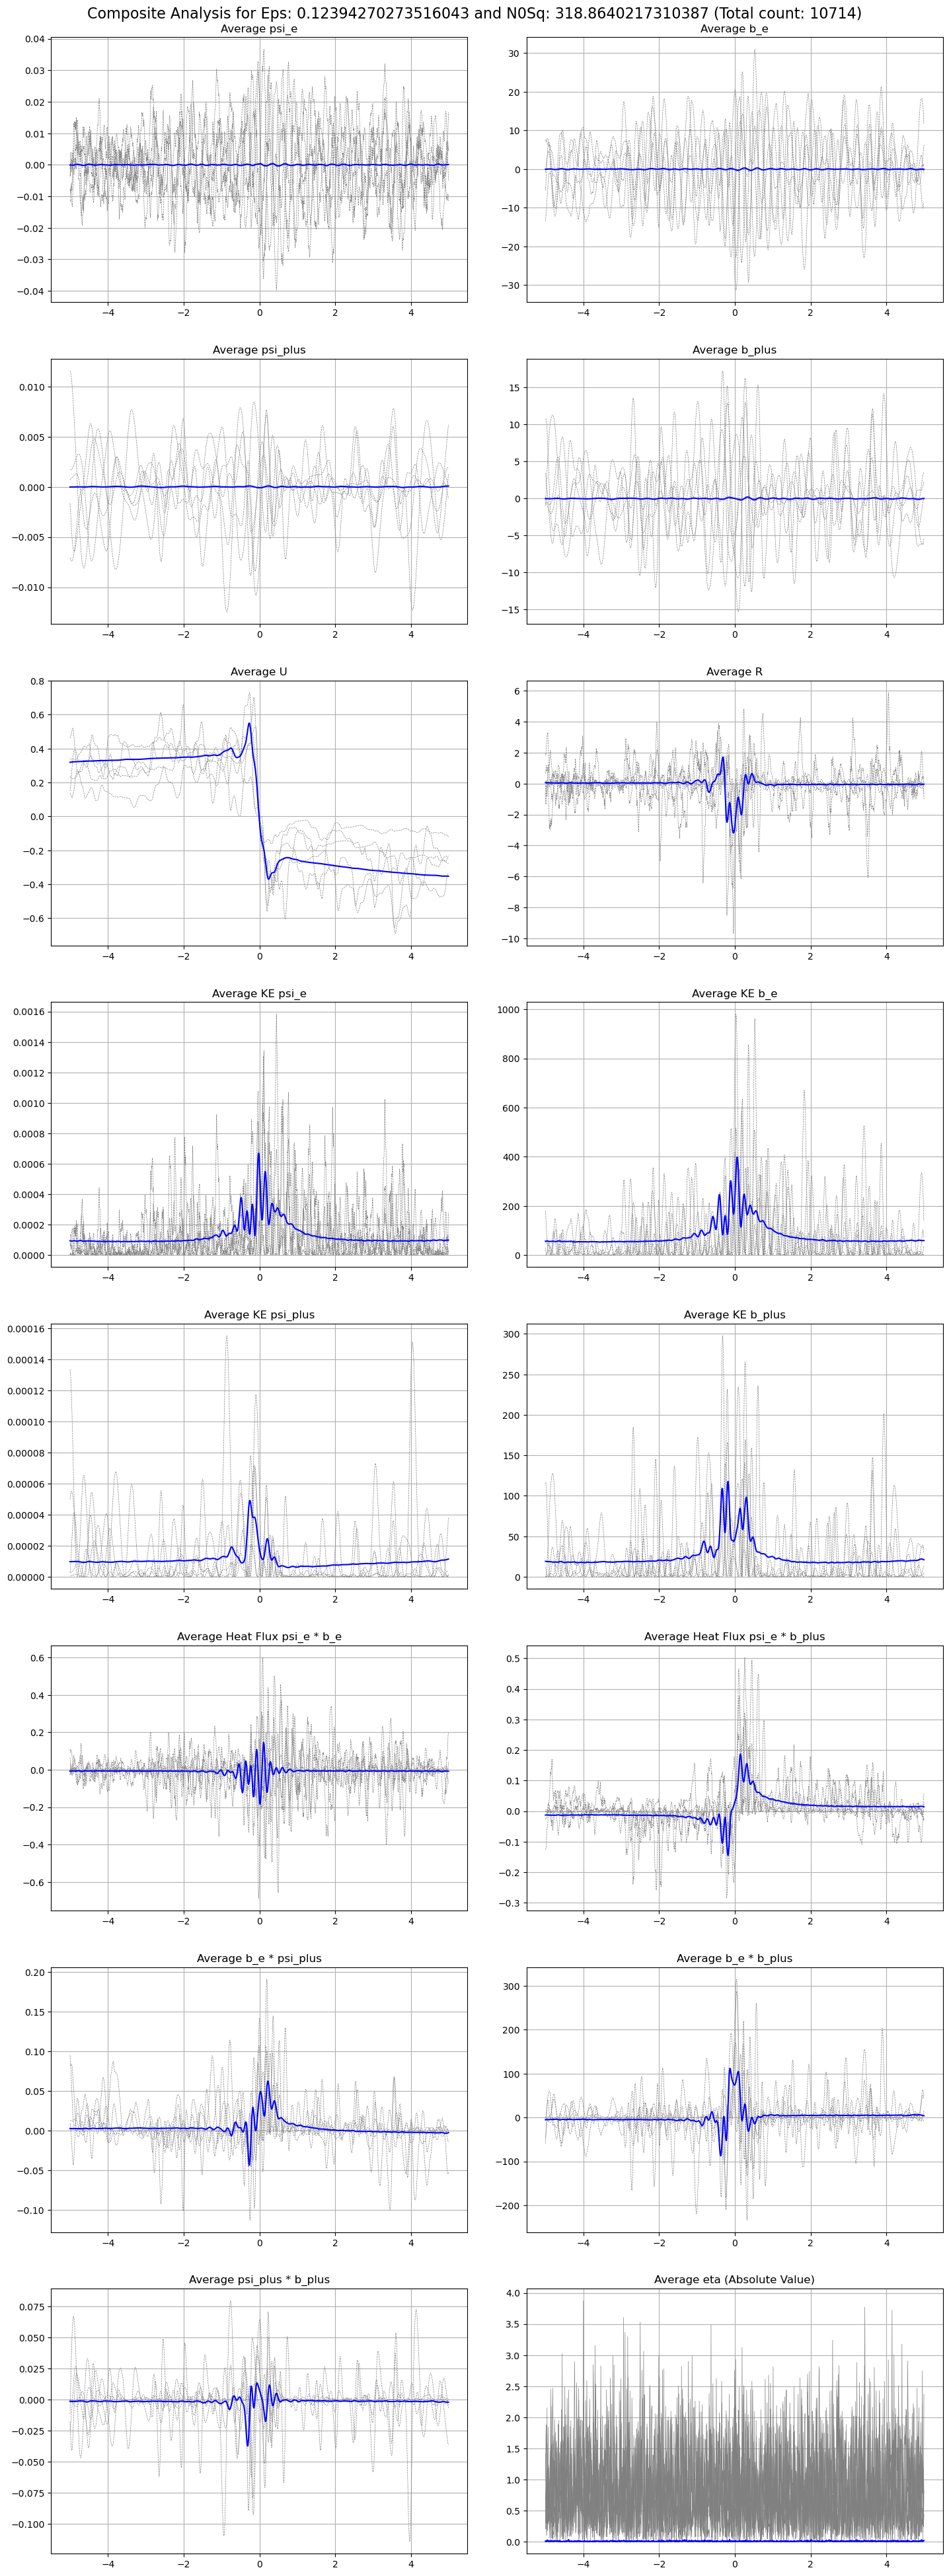

In [9]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(8, 2, figsize=(15, 40))

for i in range(5):
    axs[0, 0].plot(time_array, df['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, average_psi_e, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_title(f'Average psi_e')
axs[0, 0].grid()


for i in range(5):
    axs[0, 1].plot(time_array, df['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, average_b_e, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_title(f'Average b_e')
axs[0, 1].grid()

for i in range(5):
    axs[1, 0].plot(time_array, df['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
axs[1, 0].plot(time_array, average_psi_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_title(f'Average psi_plus')
axs[1, 0].grid()

for i in range(5):
    axs[1, 1].plot(time_array, df['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, average_b_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_title(f'Average b_plus')
axs[1, 1].grid()

for i in range(5):
    axs[2, 0].plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[2, 0].plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
axs[2, 0].set_title(f'Average U')
axs[2, 0].grid()

for i in range(5):
    axs[2, 1].plot(time_array, df['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[2, 1].plot(time_array, average_R, label='Average', linewidth=1.5, color='blue')
axs[2, 1].set_title(f'Average R')
axs[2, 1].grid()

for i in range(5):
    axs[3, 0].plot(time_array, df['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[3, 0].plot(time_array, average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 0].set_title(f'Average KE psi_e')
axs[3, 0].grid()

for i in range(5):
    axs[3, 1].plot(time_array, df['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[3, 1].plot(time_array, average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 1].set_title(f'Average KE b_e')
axs[3, 1].grid()

for i in range(5):
    axs[4, 0].plot(time_array, df['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[4, 0].plot(time_array, average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 0].set_title(f'Average KE psi_plus')
axs[4, 0].grid()

for i in range(5):
    axs[4, 1].plot(time_array, df['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[4, 1].plot(time_array, average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 1].set_title(f'Average KE b_plus')
axs[4, 1].grid()

for i in range(5):
    axs[5, 0].plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[5, 0].plot(time_array, average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[5, 0].set_title(f'Average Heat Flux psi_e * b_e')
axs[5, 0].grid()

for i in range(5):
    axs[5, 1].plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[5, 1].plot(time_array, average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[5, 1].set_title(f'Average Heat Flux psi_e * b_plus')
axs[5, 1].grid()

for i in range(5):
    axs[6, 0].plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[6, 0].plot(time_array, average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 0].set_title(f'Average b_e * psi_plus')
axs[6, 0].grid()

for i in range(5):
    axs[6, 1].plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[6, 1].plot(time_array, average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 1].set_title(f'Average b_e * b_plus')
axs[6, 1].grid()

for i in range(5):
    axs[7, 0].plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[7, 0].plot(time_array, average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[7, 0].set_title(f'Average psi_plus * b_plus')
axs[7, 0].grid()

average_eta = [[abs(i) for i in sublist] for sublist in average_eta]

for i in range(5): #Check if the average eta is the same using randn 
    axs[7, 1].plot(time_array, [abs(i[0]) for i in df['eta_list'][i]], linewidth=0.5, linestyle='-', label=f'eta_list {i}', color = 'gray')
axs[7, 1].plot(time_array, [abs(i[0]) for i in average_eta], label='Average', linewidth=1.5, color='blue')
axs[7, 1].set_title('Average eta (Absolute Value)')
axs[7, 1].grid()


plt.suptitle(f'Composite Analysis for Eps: {epsilon} and N0Sq: {N_0_squared} (Total count: {len(list(df['b_e']))})', fontsize=16)
plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout(pad = 3)

plt.show()

In [10]:
#find the lowest value of U time
#then for the corresponding time, plot the interesting variables 
#Variables of interest: kepsie, kebe, kepsiplus, kebplus, heat flux psie b plus, be psi plus  



average_U_list = average_U.tolist()
min_index = average_U_list.index(min(average_U))
min_index

524

In [11]:
trunc_k_e_psi_e_list = average_k_e_psi_e_list[524:]
trunc_k_e_b_e_list = average_k_e_b_e_list[524:]
trunc_k_e_psi_plus_list = average_k_e_psi_plus_list[524:]
trunc_k_e_b_plus_list = average_k_e_b_plus_list[524:]
trunc_heat_flux_psi_e_b_plus_list = average_heat_flux_psi_e_b_plus_list[524:]
trunc_b_e_psi_plus_list = average_b_e_psi_plus_list[524:]

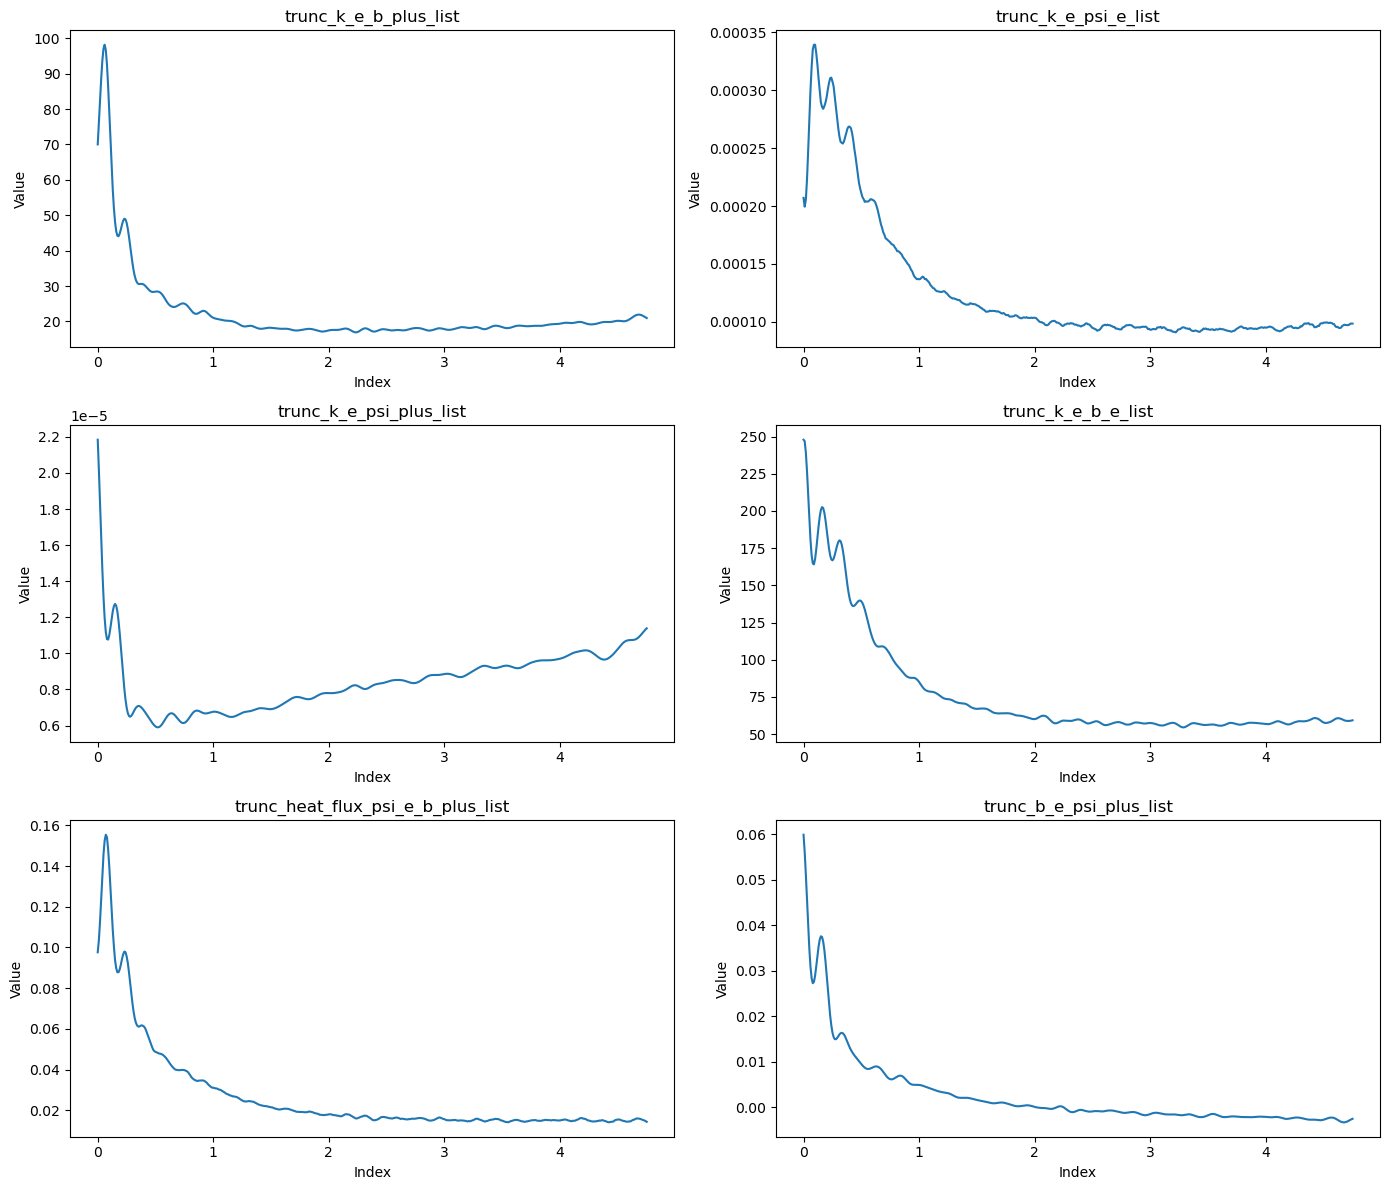

In [12]:
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
axs = axs.flatten()

x = np.linspace(0.0, 0.01 * (len(trunc_k_e_b_plus_list) - 1), len(trunc_k_e_b_plus_list))



axs[0].plot(x, trunc_k_e_b_plus_list)
axs[0].set_title('trunc_k_e_b_plus_list')
axs[0].set_xlabel('Index')
axs[0].set_ylabel('Value')

axs[1].plot(x, trunc_k_e_psi_e_list)
axs[1].set_title('trunc_k_e_psi_e_list')
axs[1].set_xlabel('Index')
axs[1].set_ylabel('Value')

axs[2].plot(x, trunc_k_e_psi_plus_list)
axs[2].set_title('trunc_k_e_psi_plus_list')
axs[2].set_xlabel('Index')
axs[2].set_ylabel('Value')

# If you have the other 3 variables (trunc_k_e_b_e_list, trunc_heat_flux_psi_e_b_plus_list, trunc_b_e_psi_plus_list) defined, plot them as well:
axs[3].plot(x, trunc_k_e_b_e_list)
axs[3].set_title('trunc_k_e_b_e_list')
axs[3].set_xlabel('Index')
axs[3].set_ylabel('Value')

axs[4].plot(x, trunc_heat_flux_psi_e_b_plus_list)
axs[4].set_title('trunc_heat_flux_psi_e_b_plus_list')
axs[4].set_xlabel('Index')
axs[4].set_ylabel('Value')

axs[5].plot(x, trunc_b_e_psi_plus_list)
axs[5].set_title('trunc_b_e_psi_plus_list')
axs[5].set_xlabel('Index')
axs[5].set_ylabel('Value')

plt.tight_layout()
plt.show()

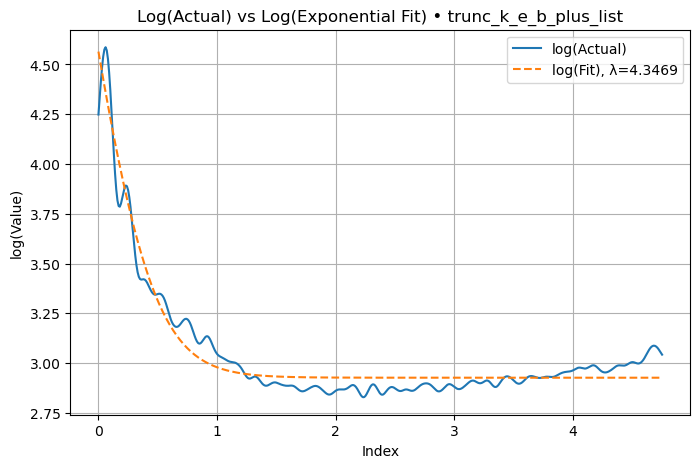

Estimated λ (lambda) for trunc_k_e_b_plus_list: 4.346906


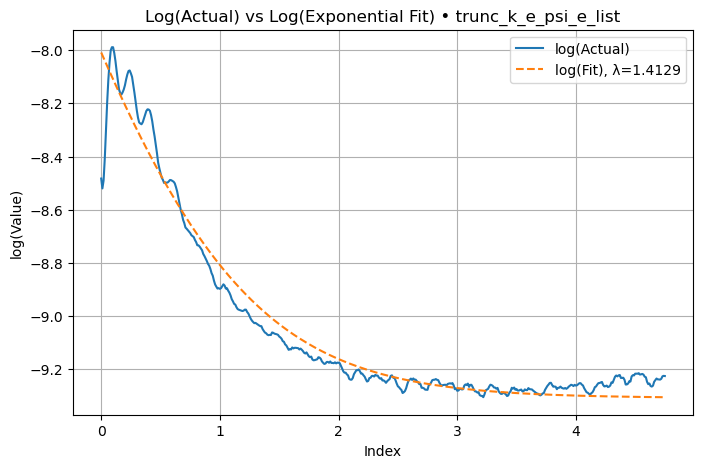

Estimated λ (lambda) for trunc_k_e_psi_e_list: 1.412887


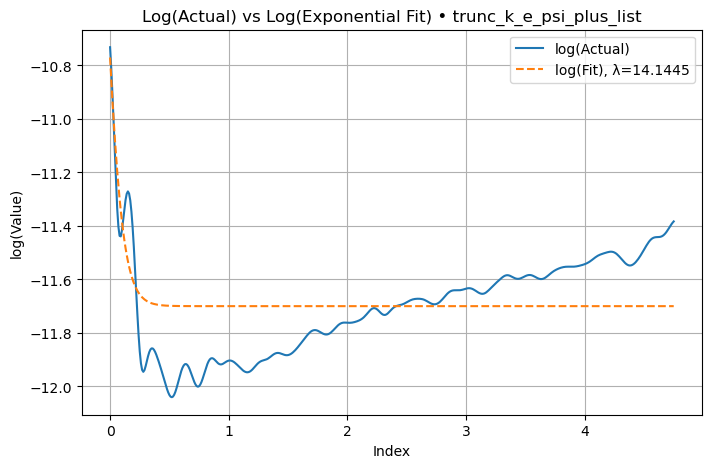

Estimated λ (lambda) for trunc_k_e_psi_plus_list: 14.144533


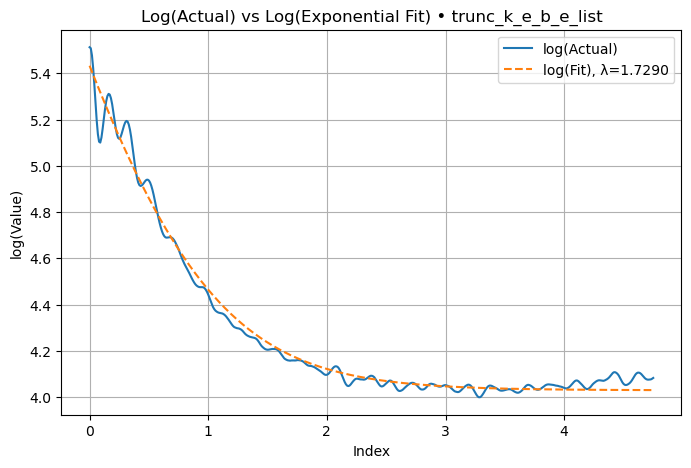

Estimated λ (lambda) for trunc_k_e_b_e_list: 1.728984


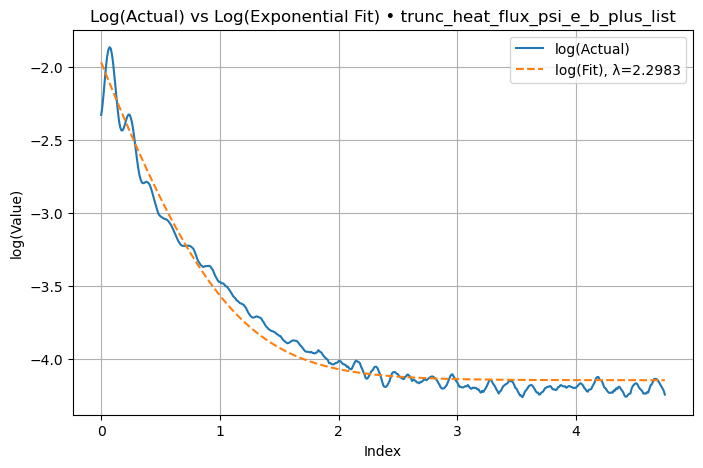

Estimated λ (lambda) for trunc_heat_flux_psi_e_b_plus_list: 2.298298


ValueError: All values for trunc_b_e_psi_plus_list must be positive to use log scale.

<Figure size 800x500 with 0 Axes>

In [13]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from typing import Iterable, Tuple, Dict, Optional

# y = a * exp(-lambd * x) + c
def exp_func(x: np.ndarray, a: float, lambd: float, c: float) -> np.ndarray:
    return a * np.exp(-lambd * x) + c


def _guess_initial_params(x: np.ndarray, y: np.ndarray) -> Tuple[float, float, float]:
    """
    Very rough initial guesses for a, lambd, c to help curve_fit.
    """
    c0 = float(np.percentile(y, 10))  # baseline-ish
    y_shift = np.maximum(y - c0, np.finfo(float).eps)
    a0 = float(y_shift.max())
    # crude decay rate guess from two points
    try:
        i1, i2 = 0, max(1, len(x) // 4)
        lambd0 = abs(np.log(y_shift[i1] / y_shift[i2]) / (x[i2] - x[i1]))
        if not np.isfinite(lambd0) or lambd0 <= 0:
            lambd0 = 0.1
    except Exception:
        lambd0 = 0.1
    return a0, lambd0, c0


def fit_exp_decay(
    x: Iterable[float],
    y: Iterable[float],
    bounds: Tuple[Tuple[float, float, float], Tuple[float, float, float]] = ((0, 0, -np.inf), (np.inf, np.inf, np.inf)),
    p0: Optional[Tuple[float, float, float]] = None,
    maxfev: int = 10000,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Fit y ≈ a * exp(-lambd * x) + c.
    Returns (params, covariance), where params = [a, lambd, c].
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape.")

    # sort by x to make the guess less chaotic
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    if p0 is None:
        p0 = _guess_initial_params(x, y)

    popt, pcov = curve_fit(exp_func, x, y, p0=p0, bounds=bounds, maxfev=maxfev)
    return popt, pcov


def plot_exp_fit(
    x: Iterable[float],
    y: Iterable[float],
    label: str,
    use_log: bool = True,
    show: bool = True,
) -> Tuple[float, float, float]:
    """
    Fit and plot. If use_log is True, plot log(actual) vs log(fit).
    Returns (a, lambd, c).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    popt, _ = fit_exp_decay(x, y)
    a, lambd, c = popt
    y_fit = exp_func(x, *popt)

    plt.figure(figsize=(8, 5))
    if use_log:
        if np.any(y <= 0) or np.any(y_fit <= 0):
            raise ValueError(f"All values for {label} must be positive to use log scale.")
        plt.plot(x, np.log(y), label="log(Actual)")
        plt.plot(x, np.log(y_fit), "--", label=f"log(Fit), λ={lambd:.4f}")
        plt.ylabel("log(Value)")
        plt.title(f"Log(Actual) vs Log(Exponential Fit) • {label}")
    else:
        plt.plot(x, y, label="Actual")
        plt.plot(x, y_fit, "--", label=f"Fit, λ={lambd:.4f}")
        plt.ylabel("Value")
        plt.title(f"Exponential Fit • {label}")

    plt.xlabel("Index")
    plt.grid(True)
    plt.legend()
    if show:
        plt.show()

    print(f"Estimated λ (lambda) for {label}: {lambd:.6f}")
    return a, lambd, c


# Example usage for multiple series:
a1, lam1, c1 = plot_exp_fit(x, trunc_k_e_b_plus_list, "trunc_k_e_b_plus_list", use_log=True)
a2, lam2, c2 = plot_exp_fit(x, trunc_k_e_psi_e_list, "trunc_k_e_psi_e_list", use_log=True)
a3, lam3, c3 = plot_exp_fit(x, trunc_k_e_psi_plus_list, "trunc_k_e_psi_plus_list", use_log=True)
a4, lam4, c4 = plot_exp_fit(x, trunc_k_e_b_e_list, "trunc_k_e_b_e_list", use_log=True)
a5, lam5, c5 = plot_exp_fit(x, trunc_heat_flux_psi_e_b_plus_list, "trunc_heat_flux_psi_e_b_plus_list", use_log=True)
a6, lam6, c6 = plot_exp_fit(x, trunc_b_e_psi_plus_list, "trunc_b_e_psi_plus_list", use_log=True)


In [ ]:
def plot_exp_fit_linearized(
    x: Iterable[float],
    y: Iterable[float],
    label: str,
    show: bool = True,
    eps: float = 1e-12,
) -> Tuple[float, float, float]:
    """
    Fit y ≈ a * exp(-λ x) + c, then plot the linearized view:
        X = x
        Y = log(y - ĉ)
    which should be ~ straight with slope -λ and intercept log(a).

    Returns (a, λ, c). Also prints R^2 in the linearized space.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    popt, _ = fit_exp_decay(x, y)
    a, lambd, c = popt

    # Shift by fitted baseline and guard tiny/negative
    y_shift = y - c
    if np.any(y_shift <= 0):
        # Nudge up by eps to allow logging without exploding
        y_shift = np.maximum(y_shift, eps)

    Y = np.log(y_shift)
    # Fitted straight line in linearized space: log(a) - λ x
    Y_fit = np.log(a) - lambd * x

    # R^2 in linearized space
    ss_res = np.sum((Y - Y_fit)**2)
    ss_tot = np.sum((Y - np.mean(Y))**2) if len(Y) > 1 else 0.0
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    # Plot points vs line
    plt.figure(figsize=(8, 5))
    plt.scatter(x, Y, s=18, label="log(y - ĉ) points")
    plt.plot(x, Y_fit, "--", label=f"linear fit, slope = -λ = {-lambd:.4f}")
    plt.xlabel("x")
    plt.ylabel("log(y - ĉ)")
    plt.title(f"Linearized exponential decay • {label}")
    plt.grid(True)
    plt.legend()
    if show:
        plt.show()

    # Optional: residuals plot to see deviations clearly
    plt.figure(figsize=(8, 3.8))
    plt.axhline(0, lw=1)
    plt.scatter(x, Y - Y_fit, s=18)
    plt.xlabel("x")
    plt.ylabel("residual: log(y - ĉ) - [log(a) - λx]")
    plt.title(f"Residuals in linearized space • {label} (R² = {r2:.4f})")
    plt.grid(True)
    if show:
        plt.show()

    print(f"{label}: a={a:.6g}, λ={lambd:.6g}, c={c:.6g}, R²_linearized={r2:.5f}")
    return a, lambd, c


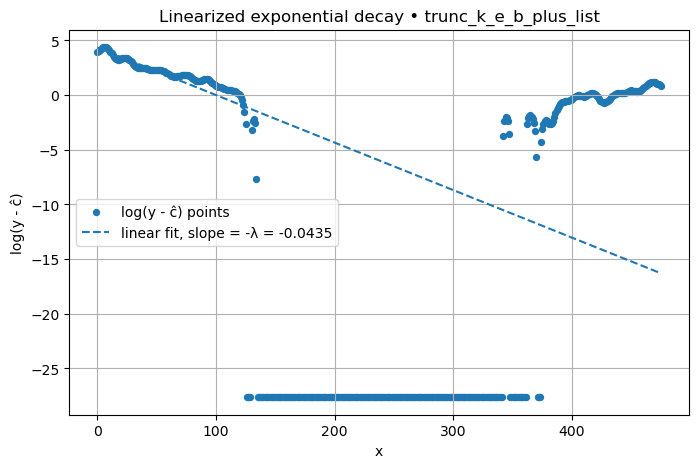

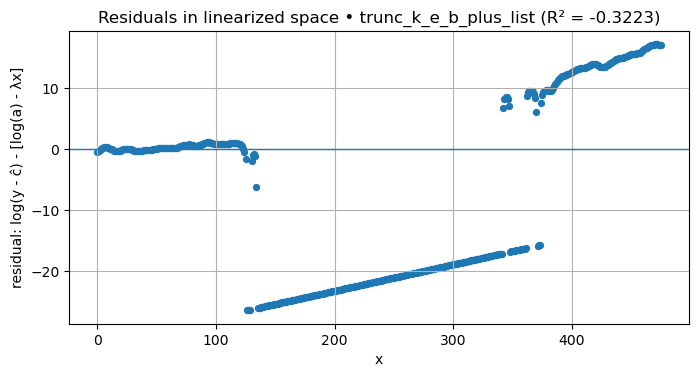

trunc_k_e_b_plus_list: a=77.3508, λ=0.0434691, c=18.6688, R²_linearized=-0.32226


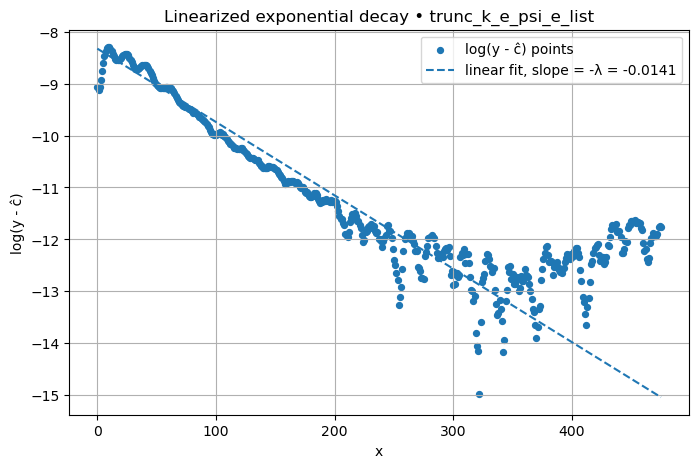

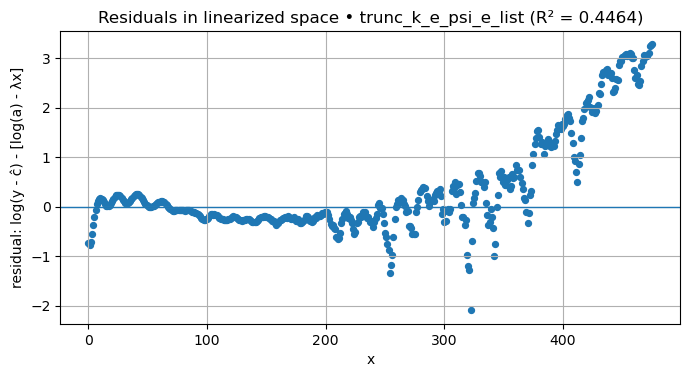

trunc_k_e_psi_e_list: a=0.000241927, λ=0.0141289, c=9.06387e-05, R²_linearized=0.44638


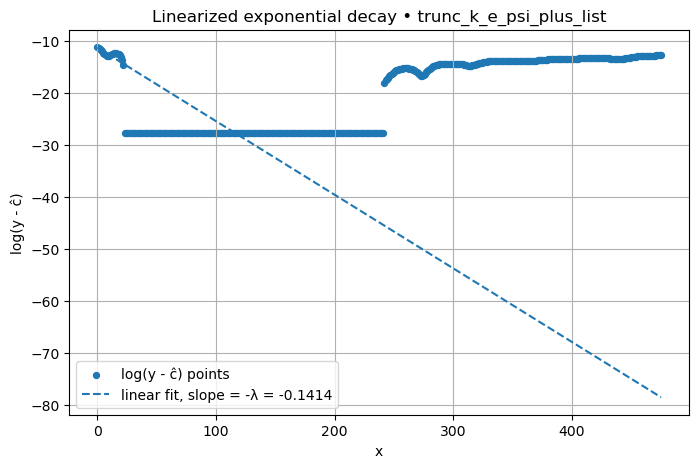

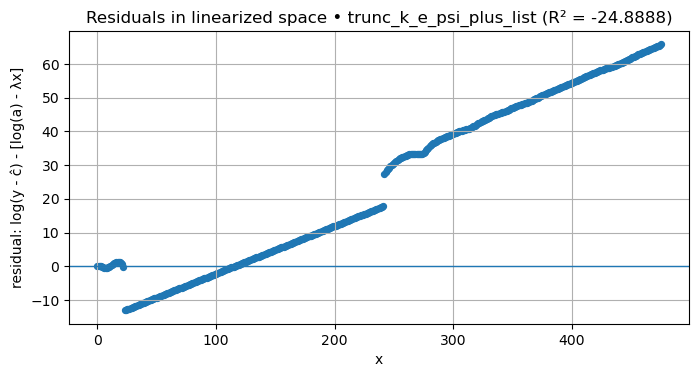

trunc_k_e_psi_plus_list: a=1.2724e-05, λ=0.141445, c=8.29429e-06, R²_linearized=-24.88883


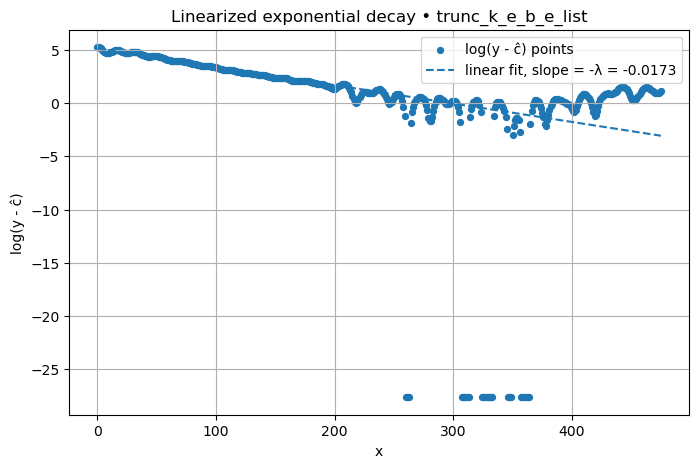

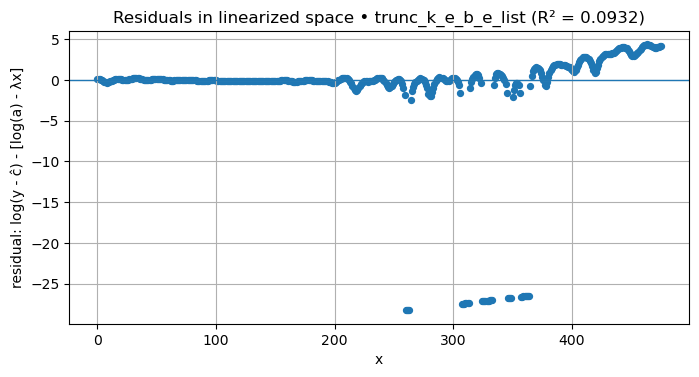

trunc_k_e_b_e_list: a=172.581, λ=0.0172898, c=56.2131, R²_linearized=0.09323


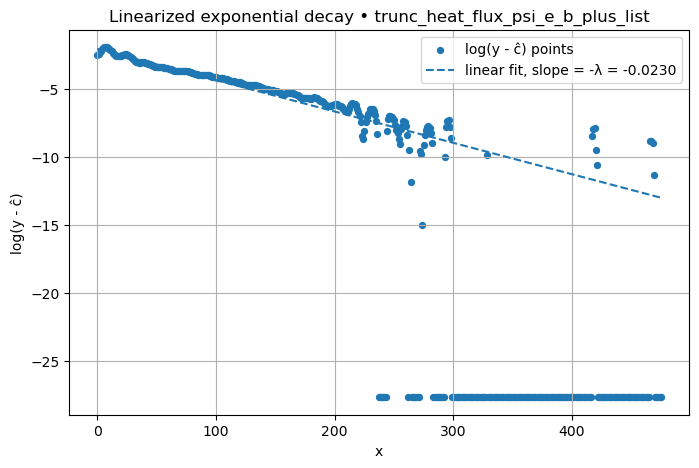

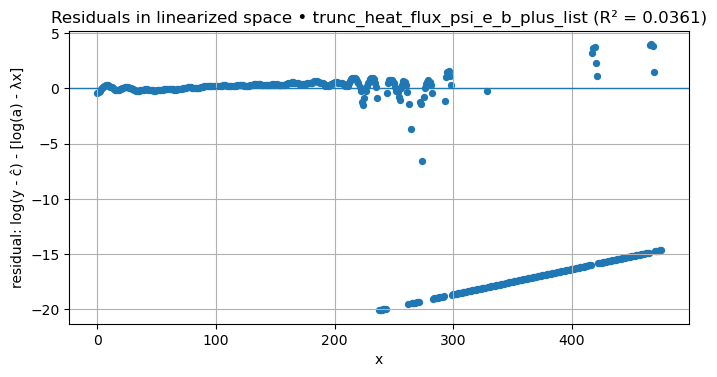

trunc_heat_flux_psi_e_b_plus_list: a=0.124188, λ=0.022983, c=0.0158264, R²_linearized=0.03609


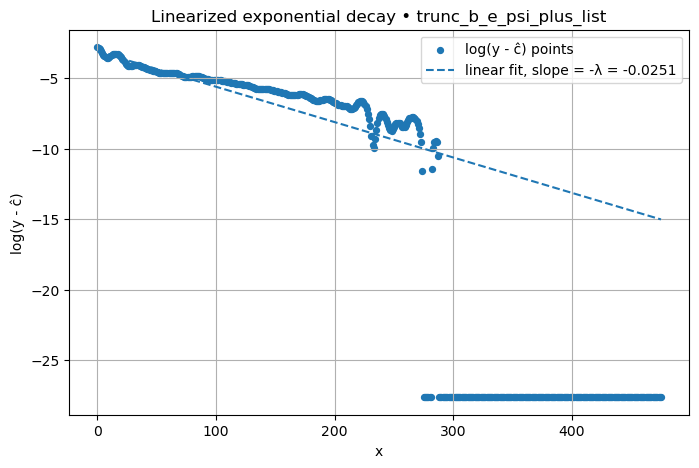

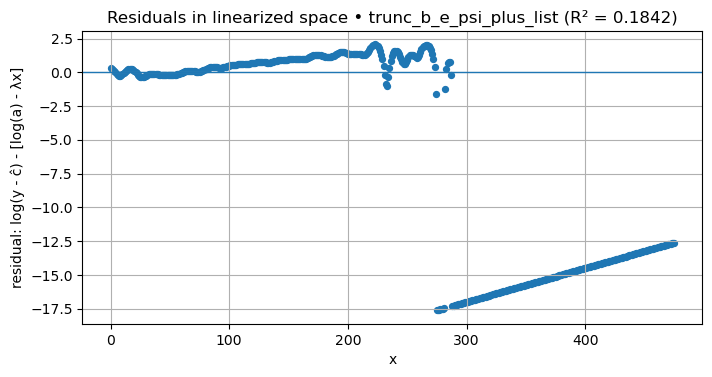

trunc_b_e_psi_plus_list: a=0.0456694, λ=0.0251146, c=-0.00115501, R²_linearized=0.18415


In [15]:
a1, lam1, c1 = plot_exp_fit_linearized(x, trunc_k_e_b_plus_list, "trunc_k_e_b_plus_list")
a2, lam2, c2 = plot_exp_fit_linearized(x, trunc_k_e_psi_e_list, "trunc_k_e_psi_e_list")
a3, lam3, c3 = plot_exp_fit_linearized(x, trunc_k_e_psi_plus_list, "trunc_k_e_psi_plus_list")
a4, lam4, c4 = plot_exp_fit_linearized(x, trunc_k_e_b_e_list, "trunc_k_e_b_e_list")
a5, lam5, c5 = plot_exp_fit_linearized(x, trunc_heat_flux_psi_e_b_plus_list, "trunc_heat_flux_psi_e_b_plus_list")
a6, lam6, c6 = plot_exp_fit_linearized(x, trunc_b_e_psi_plus_list, "trunc_b_e_psi_plus_list")


In [59]:
from sympy import Matrix, symbols, transpose, zeros, simplify
import numpy as np
import sympy as sp
import itertools
import matplotlib.pyplot as plt
import pandas as pd
from numba import jit
from scipy.stats import linregress

In [60]:
r_m_val = 0.1
k_val = 2 * np.pi * 6
m_val = 2 * np.pi * 3
m_u_val = 2 * np.pi * 7
dt_val = 0.001
total_time_val = 200
k_e_square_val = k_val**2 + m_val**2
k_plus_square_val = k_val**2 + (m_val + m_u_val)**2

In [61]:
epsilon, N_0_squared, r_m, k, m, m_u, dt, total_time = symbols('epsilon N_0_squared r_m k m m_u dt total_time')
k_plus_square, k_e_square = symbols('k_plus_square k_e_square')
Delta_U, U_star = symbols('Delta_U U_star')

Zero_array = Matrix.zeros(2, 2)
W_e = Matrix([[-1, k / k_e_square], [-k * N_0_squared, -1]])
W_plus = Matrix([[-1, -k / k_plus_square], [k * N_0_squared, -1]])
L_e_plus = Matrix([[(-k / (2 * k_e_square)) * (k_plus_square - m_u**2), 0], [0, k / 2]])
L_plus_e = Matrix([[(-k / (2 * k_plus_square)) * (m_u**2 - k_e_square), 0], [0, -k / 2]])

In [62]:
L = Matrix([
    [Zero_array, L_e_plus],
    [L_plus_e, Zero_array]
])

W = Matrix([
    [W_e, Zero_array],
    [Zero_array, W_plus]
])


In [63]:
C_star = Matrix(4, 4, symbols('C_star:16'))

Delta_C = Matrix(4, 4, symbols('Delta_C:16'))

x = Matrix([Delta_C[i, j] for i in range(4) for j in range(4)] + [Delta_U])

Delta_C_dot = Delta_U * (L * C_star + C_star * L.T) + W * Delta_C + U_star * (L * Delta_C + Delta_C * L.T) + Delta_C * W.T

Delta_U_dot = 0.25 * k * (k_plus_square - k_e_square) * Delta_C[0, 2] - r_m * Delta_U #the C element

dxdt = Matrix([Delta_C_dot[i, j] for i in range(4) for j in range(4)] + [Delta_U_dot])

A = dxdt.jacobian(x)

In [64]:
class SimulationSSD:
    def __init__(self, epsilon, N_0_squared, r_m, k, m, m_u, dt, total_time):

        #Make sure this is updated

        self.epsilon = epsilon
        self.N_0_squared = N_0_squared
        self.r_m = r_m    
        self.k = k
        self.m = m
        self.m_u = m_u
        self.dt = dt
        self.total_time = total_time
        self.num_steps = int(total_time / dt)
        self.k_e_square = k**2 + m**2
        self.k_plus_square = k**2 + (m + m_u)**2

        self.W_e = np.array([[-1, (k / self.k_e_square)], [-k * N_0_squared, -1]])
        self.W_plus = np.array([[-1, -k / self.k_plus_square], [k * N_0_squared, -1]])
        self.L_e_plus = np.array([[(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), 0],
                                  [0, k / 2]])
        self.L_plus_e = np.array([[(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), 0],
                                  [0, -k / 2]]) 
        self.U = 0.01
        self.C = np.array([[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])

        self.A_U = np.array([[-1, (k / self.k_e_square), self.U*(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), self.U*0],
                             
                             [-k * N_0_squared, -1, self.U*0, self.U*self.k/2],

                             [self.U*(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), self.U*0, -1, -self.k/self.k_plus_square],

                             [self.U*0, self.U* -k / 2,k * N_0_squared, -1]])  
    
        self.Q = np.array([[8/self.k_e_square, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])
        self.R = 0
        self.C_History = np.zeros((self.num_steps, 4, 4))              
        # self.C_History = np.zeros(self.num_steps)
        self.U_History = np.zeros(self.num_steps)
        self.R_History = np.zeros(self.num_steps)
        self.C = self.C.astype(np.float64)

    def simulate(self):
        for i in range(self.num_steps):

            self.A_U = np.array([[-1, (k / self.k_e_square), self.U*(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), self.U*0],
                             
                             [-k * N_0_squared, -1, self.U*0, self.U*self.k/2],

                             [self.U*(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), self.U*0, -1, -self.k/self.k_plus_square],

                             [self.U*0, self.U* -k / 2,k * N_0_squared, -1]]) 
                             
 
            C_dot = (self.A_U @ self.C + self.C @ np.transpose(self.A_U) + self.epsilon * self.Q) 
            U_dot = (self.R - self.r_m * self.U)

            
            self.C += C_dot * self.dt
            self.U += U_dot * self.dt
            self.R = 0.25 * self.k * (self.k_plus_square - self.k_e_square) * self.C[0][2]

            self.C_History[i] = self.C
            self.U_History[i] = self.U
            self.R_History[i] = self.R

    def make_plots(self):

        time_array = np.arange(0, self.total_time, .001)
        fig, axs = plt.subplots(1, 2, figsize = (15, 5))

       
        axs[0].plot(time_array, self.U_History)
        axs[0].set_title(f"U History")
        axs[0].grid()
        axs[1].plot(time_array, self.R_History)
        axs[1].set_title(f"R Values")
        axs[1].grid()


        plt.show()


if __name__ == "__main__":
    epsilon_values = np.array([0.12394270273516043])
    N_0_squared_values = np.array([318.8640217310387])
    combo_list = list(itertools.product(epsilon_values, N_0_squared_values))

    r_m = 0.1
    k = 2 * np.pi * 6
    m = 2 * np.pi * 3
    m_u = 2 * np.pi * 7
    dt = 0.001
    total_time = 200

    k_e_square = k**2 + m**2
    simulations = []
    for idx, (epsilon, N_0_squared) in enumerate(combo_list):
        print(f"Running simulation {idx}")
        sim = SimulationSSD(epsilon, N_0_squared, r_m, k, m, m_u, dt, total_time)
        sim.simulate()
        simulations.append(sim)
        globals()[f'sim{idx}'] = sim
        globals()[f'sim{idx}Ustar'] = sim.U_History[-1]
        globals()[f'sim{idx}Cstar'] = sim.C_History[-1]
        del sim

Running simulation 0


In [65]:
for idx in range(len(combo_list)):
    print(f"Calculating eigenvalues for simulation {idx}")
    U_star_val = globals()[f'sim{idx}Ustar']
    C_star_val = globals()[f'sim{idx}Cstar']
    epsilon_val, N_0_squared_val = combo_list[idx]

    C_star_subs = {f'C_star{i}': C_star_val[i // 4, i % 4] for i in range(16)}
    subs_dict = {'U_star': U_star_val, **C_star_subs}

    subs_dict.update({'r_m': r_m_val, 'k': k_val, 'm': m_val, 'm_u': m_u_val, 'dt': dt_val, 'total_time': total_time_val, 'k_e_square': k_e_square_val, 'k_plus_square': k_plus_square_val, 'epsilon': epsilon_val, 'N_0_squared': N_0_squared_val})
    A_subs = A.subs(subs_dict)
    # A_numeric = np.array(A_subs).astype(np.complex128)
    # eigenvalues, eigenvectors = np.linalg.eig(A_numeric)
    eigenvalues = A_subs.eigenvals()
    globals()[f'Eigenvalues{idx}'] = eigenvalues


Calculating eigenvalues for simulation 0


In [66]:
Eigenvalues0

{-2.0 - 24.8410406601771*I: 1,
 -2.0 + 24.8410406601771*I: 1,
 -2.0 - 12.9501352410212*I: 1,
 -2.0 + 12.9501352410212*I: 1,
 -1.99983939396016 - 37.8232258753707*I: 1,
 -1.99983939396016 + 37.8232258753707*I: 1,
 -1.99573492926115 - 25.0389067351013*I: 1,
 -1.99573492926115 + 25.0389067351013*I: 1,
 -2.05753719412703 - 12.6211177311107*I: 1,
 -1.56696989790767 - 12.5667338630938*I: 1,
 -2.05753719412703 + 12.6211177311107*I: 1,
 -1.56696989790767 + 12.5667338630938*I: 1,
 -0.859837169487979 + 1.17119986904774e-61*I: 1,
 -2.0 + 3.73012720596228e-59*I: 1,
 -2.0 - 3.72932229480872e-59*I: 1,
 -2.0 - 3.37066394274218e-41*I: 1,
 -2.0 + 3.37066394274218e-41*I: 1}

In [67]:
def derive_max_eigenvalue(matrix):
    eigenvalues = matrix.eigenvals()
    real_parts = []

    for eig, multiplicity in eigenvalues.items():
        real_part = simplify(eig.as_real_imag()[0]) 
        real_parts.append(real_part)

    return max(real_parts) 


In [68]:
stabilityStat = []
for idx in range(len(combo_list)):
    print(f"Calculating eigenvalues for simulation {idx}")
    U_star_val = globals()[f'sim{idx}Ustar']
    C_star_val = globals()[f'sim{idx}Cstar']
    epsilon_val, N_0_squared_val = combo_list[idx]

    C_star_subs = {f'C_star{i}': C_star_val[i // 4, i % 4] for i in range(16)}
    subs_dict = {'U_star': U_star_val, **C_star_subs}

    subs_dict.update({'r_m': r_m_val, 'k': k_val, 'm': m_val, 'm_u': m_u_val, 'dt': dt_val, 'total_time': total_time_val, 'k_e_square': k_e_square_val, 'k_plus_square': k_plus_square_val, 'epsilon': epsilon_val, 'N_0_squared': N_0_squared_val})
    A_subs = A.subs(subs_dict)
    stabilityIndicator = derive_max_eigenvalue(A_subs)
    stabilityStat.append(float(stabilityIndicator))

Calculating eigenvalues for simulation 0


In [69]:
print(stabilityStat)

[-0.8598371694879785]


Running simulation 0


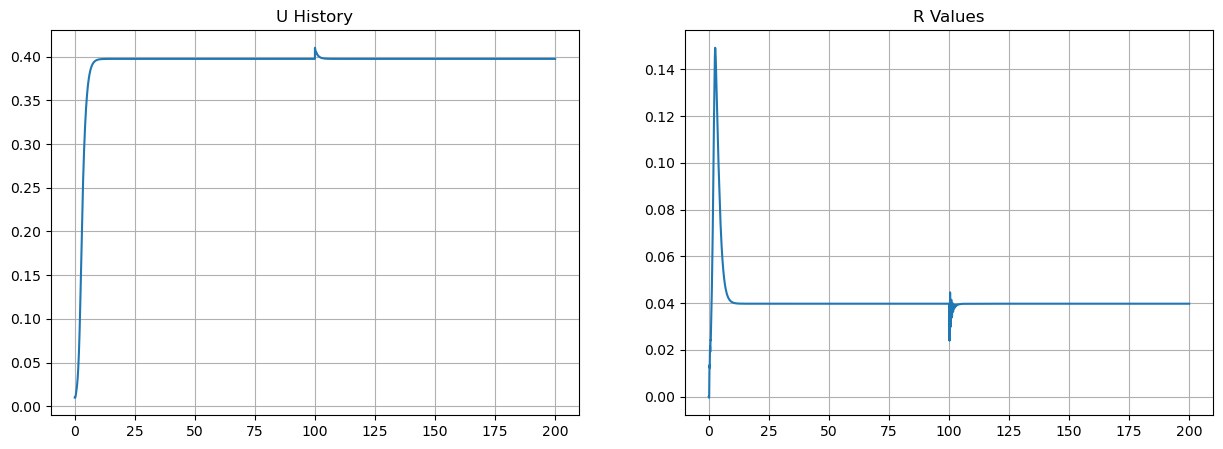

In [70]:
class SimulationSSD:
    def __init__(self, epsilon, N_0_squared, r_m, k, m, m_u, dt, total_time):

        #Make sure this is updated

        self.epsilon = epsilon
        self.N_0_squared = N_0_squared
        self.r_m = r_m    
        self.k = k
        self.m = m
        self.m_u = m_u
        self.dt = dt
        self.total_time = total_time
        self.num_steps = int(total_time / dt)
        self.k_e_square = k**2 + m**2
        self.k_plus_square = k**2 + (m + m_u)**2

        self.W_e = np.array([[-1, (k / self.k_e_square)], [-k * N_0_squared, -1]])
        self.W_plus = np.array([[-1, -k / self.k_plus_square], [k * N_0_squared, -1]])
        self.L_e_plus = np.array([[(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), 0],
                                  [0, k / 2]])
        self.L_plus_e = np.array([[(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), 0],
                                  [0, -k / 2]]) 
        self.U = 0.01
        self.C = np.array([[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])

        self.A_U = np.array([[-1, (k / self.k_e_square), self.U*(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), self.U*0],
                             
                             [-k * N_0_squared, -1, self.U*0, self.U*self.k/2],

                             [self.U*(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), self.U*0, -1, -self.k/self.k_plus_square],

                             [self.U*0, self.U* -k / 2,k * N_0_squared, -1]])  
    
        self.Q = np.array([[8/self.k_e_square, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])
        self.R = 0
        self.C_History = np.zeros((self.num_steps, 4, 4))              
        # self.C_History = np.zeros(self.num_steps)
        self.U_History = np.zeros(self.num_steps)
        self.R_History = np.zeros(self.num_steps)
        self.C = self.C.astype(np.float64)

    def simulate(self):
        for i in range(self.num_steps):
            if i == 100000:
                self.U = 0.41


            self.A_U = np.array([[-1, (k / self.k_e_square), self.U*(-k / (2 * self.k_e_square)) * (self.k_plus_square - m_u**2), self.U*0],
                             
                             [-k * N_0_squared, -1, self.U*0, self.U*self.k/2],

                             [self.U*(-k / (2 * self.k_plus_square)) * (m_u**2 - self.k_e_square), self.U*0, -1, -self.k/self.k_plus_square],

                             [self.U*0, self.U* -k / 2,k * N_0_squared, -1]]) 
                             
 
            C_dot = (self.A_U @ self.C + self.C @ np.transpose(self.A_U) + self.epsilon * self.Q) 
            U_dot = (self.R - self.r_m * self.U)

            
            self.C += C_dot * self.dt
            self.U += U_dot * self.dt
            self.R = 0.25 * self.k * (self.k_plus_square - self.k_e_square) * self.C[0][2]

            self.C_History[i] = self.C
            self.U_History[i] = self.U
            self.R_History[i] = self.R

    def make_plots(self):

        time_array = np.arange(0, self.total_time, .001)
        fig, axs = plt.subplots(1, 2, figsize = (15, 5))

       
        axs[0].plot(time_array, self.U_History)
        axs[0].set_title(f"U History")
        axs[0].grid()
        # axs[0].set_xlim(50, 75)
        # axs[0].set_ylim(.29, .295)
        axs[1].plot(time_array, self.R_History)
        axs[1].set_title(f"R Values")
        axs[1].grid()


        plt.show()


if __name__ == "__main__":
    # epsilon_values = [.24]
    epsilon_values = [0.12394270273516043]
    N_0_squared_values = [318.8640217310387]
    combo_list = list(itertools.product(epsilon_values, N_0_squared_values))

    r_m = 0.1
    k = 2 * np.pi * 6
    m = 2 * np.pi * 3
    m_u = 2 * np.pi * 7
    dt = 0.001
    total_time = 200
    simulations = []
    for idx, (epsilon, N_0_squared) in enumerate(combo_list):
        print(f"Running simulation {idx}")
        sim = SimulationSSD(epsilon, N_0_squared, r_m, k, m, m_u, dt, total_time)
        sim.simulate()
        simulations.append(sim)
        globals()[f'sim{idx}'] = sim
        globals()[f'sim{idx}Ustar'] = sim.U_History[-1]
        globals()[f'sim{idx}Cstar'] = sim.C_History[-1]
        sim.make_plots()

In [71]:
decayU = sim0.U_History[100000:105000]
decayU[-1]


0.3974567628244042

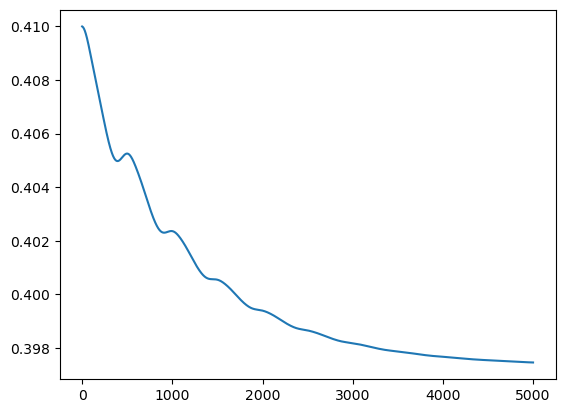

In [72]:
plt.plot(decayU)


In [73]:
decayU = decayU - sim0Ustar


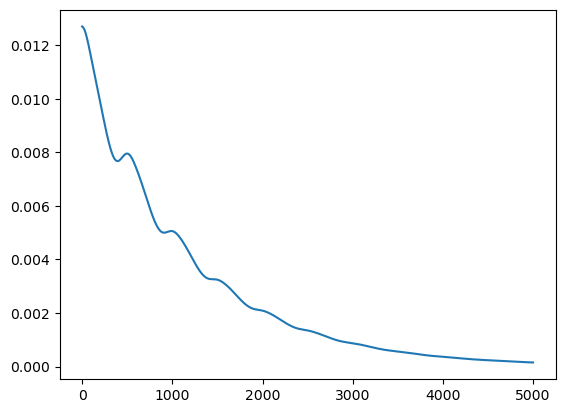

In [74]:

plt.plot(decayU)

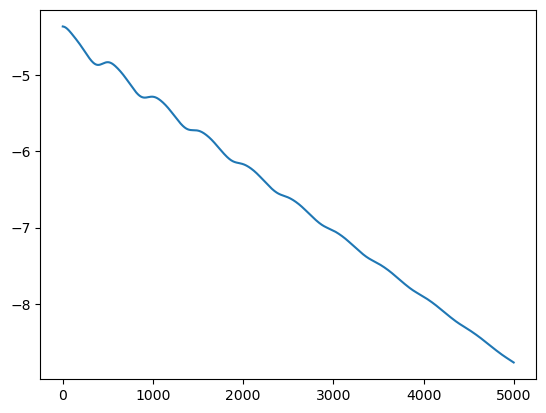

In [75]:
plt.plot(np.log(decayU))

In [76]:
slope, intercept, r_value, p_value, std_err = linregress(np.arange(0, len(decayU)), np.log(decayU))
slope

-0.0008649296348620928

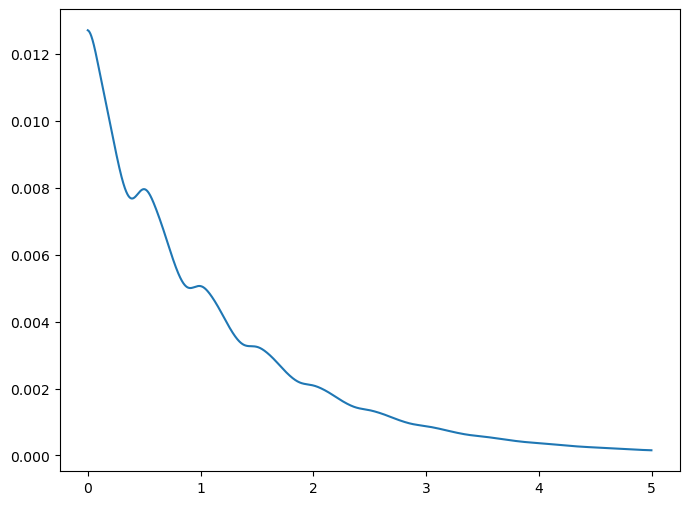

In [77]:
fig, ax = plt.subplots(1, 1, figsize = (8, 6))
decay_range = np.arange(0, len(decayU)*dt_val, dt_val)
ax.plot(decay_range, decayU)
plt.show()

In [78]:
slope, intercept, r_value, p_value, std_err = linregress(decay_range[4000:], np.log(decayU[4000:]))
slope

-0.8690648604973942